# The REST `/query` API: filtered extracts with provenance

No xarray, no zarr — one URL returns a filtered extract from any catalogued
variable, with a **data passport** attached. Endpoint:
`https://zarr.icos-cp.eu/query`. Useful parameters:

| param | meaning |
|---|---|
| `id` | catalogued variable, e.g. `icos-obspack.co2.co2` |
| `station` | station id(s), e.g. `CBW207` or `CBW207,HTM150` — the direct route (atmosphere ids are trigram+intake-height) |
| `lat_min/lat_max/lon_min/lon_max` | bounding box |
| `height_min/height_max` | sampling-height window (tall towers!) |
| `start/end` | time window (`end` exclusive) |
| `apply_qc=true` | drop QC-rejected rows (the store's recommended rule — same result as the store-route recipes) |
| `format` | `ndjson` (default), `arrow`, `parquet` |

A filter that cannot apply to a variable fails loud with HTTP 400 naming the
parameter — no silent drops.

In [1]:
import io, json, requests
import pandas as pd

# Cabauw 207 m intake by station id, year 2023 (end is exclusive). The
# spatial equivalent: a bbox (lat_min=51.9&lat_max=52.05&lon_min=4.85&
# lon_max=5.0) plus a height window (height_min=200&height_max=210).
url = ("https://zarr.icos-cp.eu/query?id=icos-obspack.co2.co2"
       "&station=CBW207"
       "&start=2023-01-01&end=2024-01-01&apply_qc=true&max_rows=200000")
raw = requests.get(url).text          # requests negotiates gzip automatically
*rows, last = raw.splitlines()
df = pd.read_json(io.StringIO("\n".join(rows)), lines=True)
passport = json.loads(last)["_passport"]
print(df.station.value_counts().to_dict(), "| columns:", list(df.columns))

{'CBW207': 8701} | columns: ['station', 'time_co2', 'latitude', 'longitude', 'co2', 'co2_qc_flag', 'sampling_height']


In [2]:
rec = passport["@graph"][1]
print("passport:", rec["totalRows"], "rows,", rec["totalBytesServed"], "bytes,",
      "accessed", rec["dateAccessed"])
print("stations:", rec["stations"])
print("citation:", str(rec.get("citation", ""))[:120], "…")
with open("query_passport.json", "w") as f:
    json.dump(passport, f, indent=2)
print("saved → query_passport.json")

passport: 8701 rows, 1383169 bytes, accessed 2026-08-17T17:14:34Z
stations: ['CBW207']
citation: ICOS RI, Adame, J., Allen, G., Apadula, F., Arnold, S., Arriga, N., Baráth, B.Á., Bergamaschi, P., Biermann, T., Blanc,  …
saved → query_passport.json


## Bulk extracts: `format=arrow`

For anything beyond a station-year, ask for Arrow: ~10× smaller than ndjson
and it parses in milliseconds. The passport rides in the schema metadata.

In [3]:
import time
import pyarrow as pa

t0 = time.perf_counter()
buf = requests.get(
    "https://zarr.icos-cp.eu/query?id=icos-obspack.co2.co2"
    "&station=CBW207&max_rows=500000&format=arrow").content
tbl = pa.ipc.open_stream(pa.BufferReader(buf)).read_all()
dt = time.perf_counter() - t0
print(f"{tbl.num_rows:,} rows ({len(buf)/1e6:.1f} MB) in {dt:.1f} s — "
      "the station's FULL record")
arrow_passport = json.loads(tbl.schema.metadata[b"data_passport"])
big = tbl.to_pandas()
big.head(3)

227,207 rows (3.5 MB) in 0.3 s — the station's FULL record


,station,time_co2,co2,latitude,longitude,co2_qc_flag,sampling_height
0,CBW207,1992-10-23 13:30:00,360.125000,51.970299,4.9264,O,207.0
1,CBW207,1992-10-23 14:30:00,361.331024,51.970299,4.9264,O,207.0
2,CBW207,1992-10-23 15:30:00,361.537018,51.970299,4.9264,O,207.0


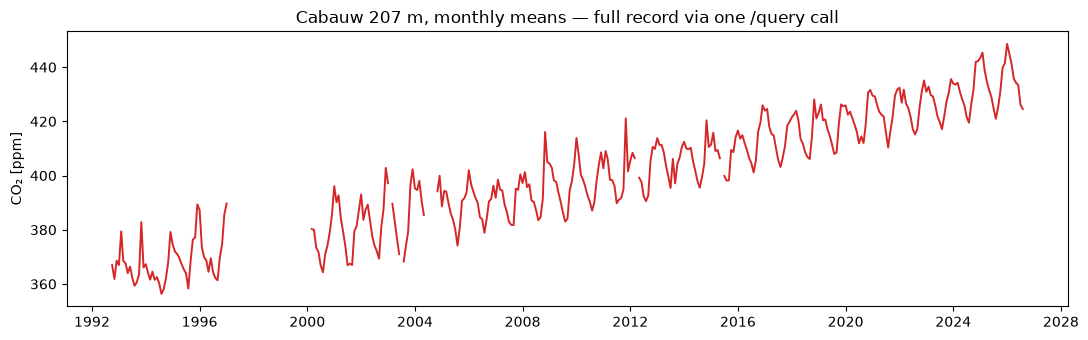

In [4]:
import matplotlib.pyplot as plt

big["t"] = pd.to_datetime(big["time_co2"])
m = (big.dropna(subset=["co2"]).set_index("t")["co2"]
        .resample("MS").mean())
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(m.index, m.values, lw=1.4, color="tab:red")
ax.set_ylabel("CO₂ [ppm]")
ax.set_title("Cabauw 207 m, monthly means — full record via one /query call")
fig.tight_layout()

**Other stores, same recipe** — swap the `id`:
`icos-socat._obs.pCO2` (ocean, supports `reduce=track`),
`icos-fluxnet._combined-fluxnet_dd.GPP_NT_VUT_REF` (ecosystem),
`socat-gridded.fco2_ave_weighted` (gridded). Discover ids at
`https://zarr.icos-cp.eu/variables`; machine-readable per-store guides live at
`https://zarr.icos-cp.eu/llms.txt`. All data CC-BY-4.0 — cite via the passport.